### ReAct agent from scratch with Gemini and LangGraph

LangGraph offers a prebuilt ReAct agent ( create_react_agent), that shines when you need more control and customization for your ReAct implementations. This guide will show you a simplified version.

LangGraph models agents as graphs using three key components:

    State: Shared data structure (typically TypedDict or Pydantic BaseModel) representing the application's current snapshot.

    Nodes: Encodes logic of your agents. They receive the current State as input, perform some computation or side-effect, and return an updated State, such as LLM calls or tool calls.
    
    Edges: Define the next Node to execute based on the current State, allowing for conditional logic and fixed transitions.


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

LangGraph provides a helper function, add_messages, for updating state message lists. It functions as a reducer, taking the current list, plus the new messages, and returns a combined list. It handles updates by message ID and defaults to an "append-only" behavior for new, unseen messages.

In [2]:
from typing import Annotated, Sequence, TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    """ The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]
    no_of_steps: int
    

In [22]:
from langchain_core.tools import tool
from geopy.geocoders import Nominatim
from pydantic import BaseModel, Field
import requests

geolocator = Nominatim(user_agent = "weather_app")

class SearchInput(BaseModel):
    location: str =  Field(description=" The city and state, eg., San Francisco")
    date: str =  Field(description = "the forecasting date for when to get the weather format (yyyy-mm-dd)" )
    
@tool("get_weather_forecast", args_schema = SearchInput, return_direct = True)
def get_weather_forecast(location: str, date: str):
    """Retrives the weather using Open-Meteo API.
    
    Takes a given location(city) and a date (yyyy-mm-dd).
    
    Returns:
    A dict with the time and temeperatur for each hour.
    """
    location = geolocator.geocode(location)
    if location:
        try:
            response = requests.get(f"https://api.open-meteo.com/v1/forecast?latitude={location.latitude}&longitude={location.longitude}&hourly=temperature_2m&start_date={date}&end_date={date}")
            data = response.json()
            return dict(zip(data["hourly"]["time"], data["hourly"]["temperature_2m"]))
        except Exception as e:
            return {"error": str(e)}
    else:
        return {"error": "Location not found"}

tools = [get_weather_forecast]

In [26]:
from datetime import datetime
from langchain_google_genai import ChatGoogleGenerativeAI

# Create LLM class
llm = ChatGoogleGenerativeAI(
    model= "gemini-3.1-flash-lite",
    temperature=1.0,
    max_retries=2,
)

# Bind tools to the model
model = llm.bind_tools([get_weather_forecast])
print(datetime.today().date())
# Test the model with tools
res=model.invoke(f"What is the weather in Ahmedabad on {datetime.today().date()}?")

print(res)



2026-05-25
content=[] additional_kwargs={'function_call': {'name': 'get_weather_forecast', 'arguments': '{"location": "Ahmedabad", "date": "2026-05-25"}'}, '__gemini_function_call_thought_signatures__': {'c8fd9184-0ae7-41bf-9fd5-fb07cb4cdea6': 'EjQKMgEMOdbHdupz0q+oWsYmai4OJTsGhsqw6OxYQsfXC5DC6DFkodwPqPi/GWIlO/urau+A'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019e5e90-2736-7d90-b9ee-30104e08ecf8-0' tool_calls=[{'name': 'get_weather_forecast', 'args': {'location': 'Ahmedabad', 'date': '2026-05-25'}, 'id': 'c8fd9184-0ae7-41bf-9fd5-fb07cb4cdea6', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 157, 'output_tokens': 34, 'total_tokens': 191, 'input_token_details': {'cache_read': 0}}


The last step before you can run your agent is to define your nodes and edges. In this example, you have two nodes and one edge.

    call_tool node that executes your tool method. LangGraph has a prebuilt node for this called ToolNode.
    call_model node that uses the model_with_tools to call the model.
    should_continue edge that decides whether to call the tool or the model.


In [29]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableConfig
tools_by_name = {tool.name: tool for tool in tools}

#Define out tool node
def call_tool(state: AgentState):
    outputs = []
    # Iterate over the tool calss in the the last messgae
    for tool_call in state["messages"][-1].tool_calls:
        #Get the tool by name
        tool_result =  tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=tool_result,
                name = tool_call["name"],
                tool_call_id = tool_call["id"],
            )
        )
    return {"messages": outputs}

def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    #Invoke the model with the system prommpt and the messages
    response =  model.invoke(state["messages"], config)
    # This returns a list, which combines with the existing messages state
    # using the add_messages reducer.
    return {"messages":[response]}


#Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    # If the last message is not a tool call, then finish
    if not messages[-1].tool_calls:
        return "end"
    # default to continue
    return "continue"


In [31]:
from langgraph.graph import StateGraph, END

#Define a new graph with our state
workflow = StateGraph(AgentState)

# 1. Add the nodes
workflow.add_node("llm", call_model)
workflow.add_node("tools", call_tool)
# 2. Set the entrypoint as 'agent', this is the first node called
workflow.set_entry_point("llm")
# 3. Add a condiiona; edge after the 'llm' node is called
workflow.add_conditional_edges(
    "llm",
    should_continue,
    {
        "continue": "tools",
        "end":END,
    },
)
# 4. Add a normal edge after 'tools' is called, 'llm' node is called next.
workflow.add_edge("tools", "llm")
# Now we can compile and visualize our graph
graph = workflow.compile()


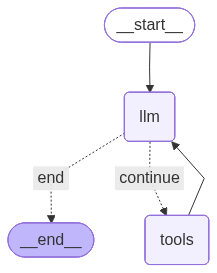

In [32]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [34]:
from datetime import datetime
# Create our initial message dictionary
inputs = {"messages": [("user", f"What is the weather in ahmedabad on {datetime.today().date()}?")]}

# call our graph with streaming to see the steps
for state in graph.stream(inputs, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()


================================ Human Message =================================

What is the weather in ahmedabad on 2026-05-25?
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather_forecast (49d92e56-35e5-4c8b-8573-9d0acb83e8e9)
 Call ID: 49d92e56-35e5-4c8b-8573-9d0acb83e8e9
  Args:
    location: Ahmedabad
    date: 2026-05-25
================================= Tool Message =================================
Name: get_weather_forecast

{'2026-05-25T00:00': 28.5, '2026-05-25T01:00': 28.1, '2026-05-25T02:00': 28.9, '2026-05-25T03:00': 30.2, '2026-05-25T04:00': 32.0, '2026-05-25T05:00': 34.1, '2026-05-25T06:00': 36.8, '2026-05-25T07:00': 39.1, '2026-05-25T08:00': 40.7, '2026-05-25T09:00': 41.5, '2026-05-25T10:00': 42.1, '2026-05-25T11:00': 42.2, '2026-05-25T12:00': 41.8, '2026-05-25T13:00': 41.5, '2026-05-25T14:00': 38.3, '2026-05-25T15:00': 36.0, '2026-05-25T16:00': 35.3, '2026-05-25T17:00': 35.0, '2026-05-25T18:00': 33.5, '2026-0

In [35]:
state["messages"].append(("user", "Would it be warmer in Rajkot?"))

for state in graph.stream(state, stream_mode="values"):
    last_message = state["messages"][-1]
    last_message.pretty_print()


================================ Human Message =================================

Would it be warmer in Rajkot?
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather_forecast (c0dce9bd-bed1-41ae-bd29-3afb8ca179e1)
 Call ID: c0dce9bd-bed1-41ae-bd29-3afb8ca179e1
  Args:
    location: Rajkot
    date: 2026-05-25
================================= Tool Message =================================
Name: get_weather_forecast

{'2026-05-25T00:00': 27.7, '2026-05-25T01:00': 27.5, '2026-05-25T02:00': 28.5, '2026-05-25T03:00': 30.0, '2026-05-25T04:00': 31.9, '2026-05-25T05:00': 34.5, '2026-05-25T06:00': 37.0, '2026-05-25T07:00': 39.0, '2026-05-25T08:00': 40.2, '2026-05-25T09:00': 40.8, '2026-05-25T10:00': 41.0, '2026-05-25T11:00': 39.9, '2026-05-25T12:00': 37.5, '2026-05-25T13:00': 35.3, '2026-05-25T14:00': 33.8, '2026-05-25T15:00': 32.7, '2026-05-25T16:00': 31.0, '2026-05-25T17:00': 29.7, '2026-05-25T18:00': 28.9, '2026-05-25T19:00': 28.4, '2

### ReAct agent from scratch with OpenAI and LangGraph

In [36]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo",
                 api_key = os.getenv("API_KEY"),
                 base_url= os.getenv("BASE_URL"))


In [37]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [39]:
tools = [add, multiply,divide]
llm_with_tools = llm.bind_tools(tools)

In [40]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

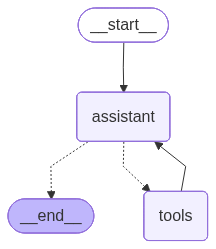

In [41]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine the control flow
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
graph = builder.compile()
graph

In [44]:
messages = [HumanMessage(content="Add 3 and 4. Multiply the output by 2. Then again Divide the new output by 5")]
messages = graph.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 3 and 4. Multiply the output by 2. Then again Divide the new output by 5
================================== Ai Message ==================================
Tool Calls:
  add (call_Jnalp55KDhi1OOFp57jOz5TI)
 Call ID: call_Jnalp55KDhi1OOFp57jOz5TI
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Tool Calls:
  multiply (call_YgD5XwJxjQPRcFTX0odVQeld)
 Call ID: call_YgD5XwJxjQPRcFTX0odVQeld
  Args:
    a: 7
    b: 2
  divide (call_JHh8G5Xi0F9aeHWFv8NBclmC)
 Call ID: call_JHh8G5Xi0F9aeHWFv8NBclmC
  Args:
    a: 14
    b: 5
================================= Tool Message =================================
Name: multiply

14
================================= Tool Message =================================
Name: divide

2.8
================================== Ai Mes